In [3]:
import data

import typing as tt
import pandas as pd
import numpy as np
import tqdm
import torch
from torch import nn
import albumentations as A
from torch.utils.data import DataLoader
from transformers import ViTForImageClassification
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, 
    roc_auc_score, auc, precision_recall_curve
)
from PIL import Image

import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
pio.templates.default = 'plotly_white'

In [4]:
rescale_transform = A.Compose([
    A.LongestMaxSize(224),
    A.PadIfNeeded(224, 224, fill=data.FILL_COLOR),
])

In [5]:
images_path = data.get_images_path()
images_classes = data.get_classes(images_path)
images_classes_en = data.get_english_classes(images_classes)

samples = data.get_sorted_samples(images_path)
train_samples, val_samples, test_samples = data.split_train_val_test(
    samples, seed=data.TRAIN_TEST_DEFAULT_SEED, shuffle=True)

In [6]:
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')
output_layer = nn.Linear(model.classifier.in_features, len(images_classes))
model.classifier = output_layer

device = torch.device("cpu")
MODEL_NAME = "models/04-vt-last-layer_best.model"
weights_dict = torch.load(MODEL_NAME, map_location=device, weights_only=True)
output_layer.load_state_dict(weights_dict)
model.eval()

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear

In [7]:
BATCH_SIZE = 128
val_dataset = data.ImagesDataset(images_classes, val_samples, rescale=rescale_transform)
val_loader = DataLoader(val_dataset, BATCH_SIZE)
test_dataset = data.ImagesDataset(images_classes, test_samples, rescale=rescale_transform)
test_loader = DataLoader(test_dataset, BATCH_SIZE)

In [8]:
with torch.no_grad():
    pred_probs = []
    pred_classes = []
    true_classes = []
    for batch_x, batch_y in tqdm.tqdm(test_loader):
        out_t = model(batch_x).logits
        probs_t = torch.softmax(out_t, -1)
        preds_t = torch.argmax(probs_t, -1)
        true_classes.extend(batch_y.detach().numpy())
        pred_classes.extend(preds_t.detach().numpy())
        pred_probs.extend(probs_t.detach().numpy())
pred_probs = np.array(pred_probs)
pred_classes = np.array(pred_classes)
true_classes = np.array(true_classes)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:56<00:00,  2.96s/it]


In [9]:
confusion_matrix(true_classes, pred_classes)

array([[469,   1,   0,   0,   0,   3,   3,   1,   0,   1],
       [  2, 251,   0,   0,   0,   0,   1,   0,   0,   0],
       [  0,   0, 112,   0,   0,   0,   0,   0,   0,   0],
       [  1,   0,   0, 158,   1,   0,   0,   0,   3,   0],
       [  3,   0,   0,   0, 304,   0,   0,   0,   0,   0],
       [  1,   0,   0,   0,   0, 127,   0,   0,   0,   0],
       [  1,   2,   2,   0,   0,   0, 160,   2,   0,   0],
       [  0,   3,   0,   0,   0,   0,   1, 139,   0,   1],
       [  1,   1,   0,   4,   0,   0,   0,   0, 494,   0],
       [  2,   0,   0,   0,   1,   0,   0,   0,   0, 165]])

In [10]:
print(classification_report(true_classes, pred_classes, target_names=images_classes_en))

              precision    recall  f1-score   support

         dog       0.98      0.98      0.98       478
       horse       0.97      0.99      0.98       254
    elephant       0.98      1.00      0.99       112
   butterfly       0.98      0.97      0.97       163
     chicken       0.99      0.99      0.99       307
         cat       0.98      0.99      0.98       128
         cow       0.97      0.96      0.96       167
       sheep       0.98      0.97      0.97       144
      spider       0.99      0.99      0.99       500
    squirrel       0.99      0.98      0.99       168

    accuracy                           0.98      2421
   macro avg       0.98      0.98      0.98      2421
weighted avg       0.98      0.98      0.98      2421



Using multiclass ROC curve One-vs-Rest: 
https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html

In [11]:
df_dict = {"fpr": [], "tpr": [], "class": []}
for i, class_name in enumerate(images_classes_en):
    true_i = (true_classes == i).astype(np.int32)
    fpr, tpr, _ = roc_curve(true_i, pred_probs[:, i])
    auc_score = auc(fpr, tpr) * 100
    label = f"{class_name}, auc={auc_score:.2f}"
    df_dict['fpr'].extend(fpr)
    df_dict['tpr'].extend(tpr)
    df_dict['class'].extend([label for _ in range(len(fpr))])

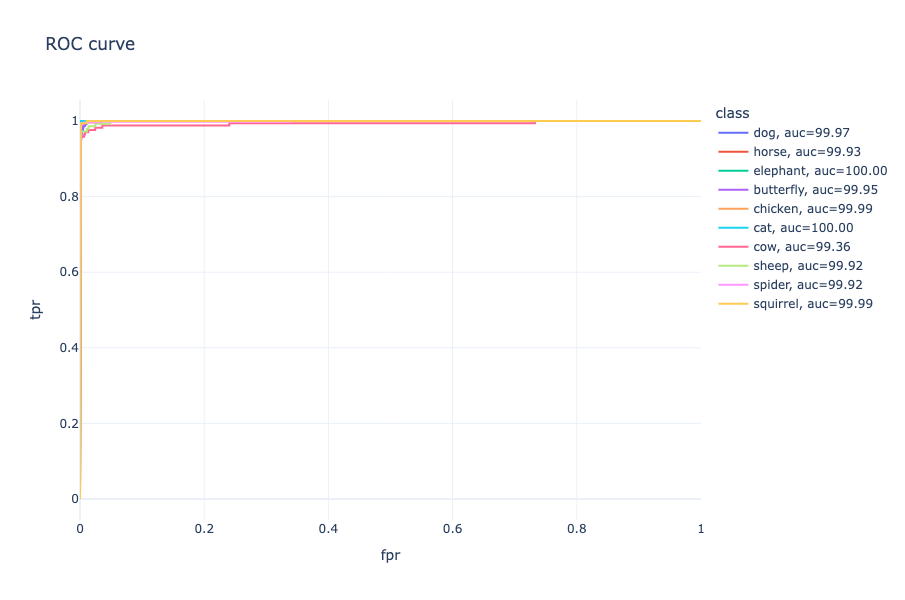

In [12]:
df = pd.DataFrame(df_dict)
px.line(df, x='fpr', y='tpr', color='class', 
        width=800, height=600, title="ROC curve")

Let's try to tune the threshold for the dog class (which has index 0)

In [14]:
with torch.no_grad():
    val_pred_probs = []
    val_pred_classes = []
    val_true_classes = []
    for batch_x, batch_y in tqdm.tqdm(val_loader):
        out_t = model(batch_x).logits
        probs_t = torch.softmax(out_t, -1)
        preds_t = torch.argmax(probs_t, -1)
        val_true_classes.extend(batch_y.detach().numpy())
        val_pred_classes.extend(preds_t.detach().numpy())
        val_pred_probs.extend(probs_t.detach().numpy())
val_pred_probs = np.array(val_pred_probs)
val_pred_classes = np.array(val_pred_classes)
val_true_classes = np.array(val_true_classes)
print(classification_report(val_true_classes, val_pred_classes, target_names=images_classes_en))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:55<00:00,  2.93s/it]

              precision    recall  f1-score   support

         dog       0.97      0.98      0.98       477
       horse       0.97      0.99      0.98       246
    elephant       0.97      0.98      0.98       101
   butterfly       0.98      0.97      0.97       174
     chicken       1.00      0.99      1.00       326
         cat       0.98      0.95      0.96       136
         cow       0.97      0.96      0.97       199
       sheep       0.98      0.98      0.98       130
      spider       0.99      0.99      0.99       449
    squirrel       0.99      0.99      0.99       183

    accuracy                           0.98      2421
   macro avg       0.98      0.98      0.98      2421
weighted avg       0.98      0.98      0.98      2421



In [15]:
true_dog = (val_true_classes == 0).astype(np.int32)
probs_dog = val_pred_probs[:, 0]

In [16]:
precision, recall, threshold = precision_recall_curve(true_dog, probs_dog)

In [17]:
f1 = 2*precision[:-1]*recall[:-1] / (precision[:-1] + recall[:-1] + 1e-10)
idx = np.argmax(f1)
best_threshold = threshold[idx]
best_f1 = f1[idx]
best_threshold, best_f1

(np.float32(0.53654116), np.float64(0.9801047119918849))

In [18]:
import matplotlib.pylab as plt
import itertools

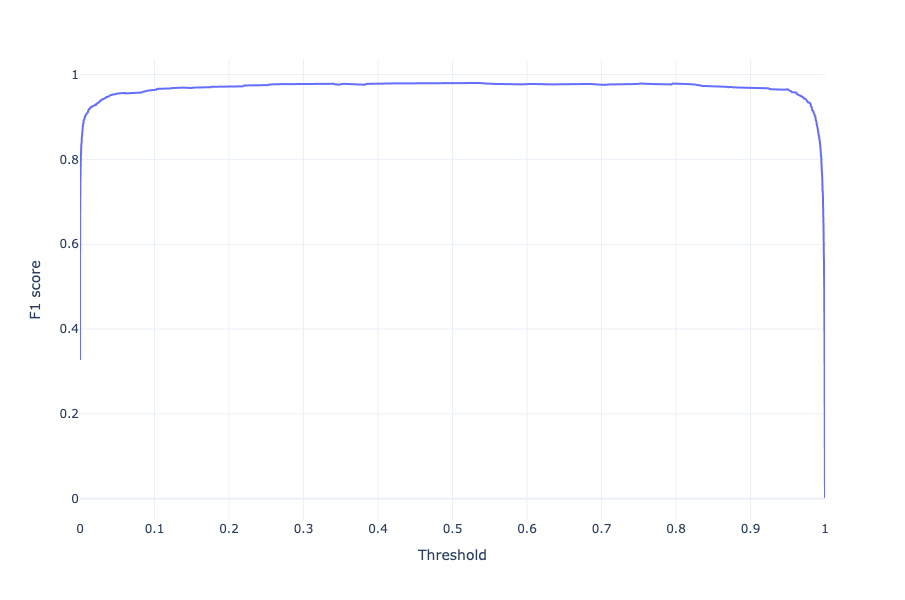

In [19]:
px.line(x=threshold, y=f1, width=800, height=600, 
        labels={"x": "Threshold", "y": "F1 score"})

Compute thresholds for all classes

In [20]:
df_dict = {"threshold": [], "f1": [], "class": []}
class_thresholds = {}
for i, class_name in enumerate(images_classes_en):
    true_i = (val_true_classes == i).astype(np.int32)
    precision, recall, threshold = precision_recall_curve(
        true_i, val_pred_probs[:, i])
    f1 = 2*precision[:-1]*recall[:-1] / (precision[:-1] + recall[:-1] + 1e-10)
    idx = np.argmax(f1)
    best_threshold = threshold[idx]
    best_f1 = f1[idx]
    print(f"{class_name:15s} best F1={best_f1*100:.2f}%, "
          f"threshold={best_threshold:.5f}")
    label = f"{class_name}, f1={best_f1*100:.2f}%"
    df_dict['threshold'].extend(threshold)
    df_dict['f1'].extend(f1)
    df_dict['class'].extend([label for _ in range(len(f1))])
    class_thresholds[i] = best_threshold

dog             best F1=98.01%, threshold=0.53654
horse           best F1=98.37%, threshold=0.73059
elephant        best F1=98.04%, threshold=0.37574
butterfly       best F1=97.99%, threshold=0.30671
chicken         best F1=99.69%, threshold=0.34251
cat             best F1=97.44%, threshold=0.19865
cow             best F1=97.22%, threshold=0.54016
sheep           best F1=98.08%, threshold=0.30473
spider          best F1=99.11%, threshold=0.40246
squirrel        best F1=99.46%, threshold=0.26257


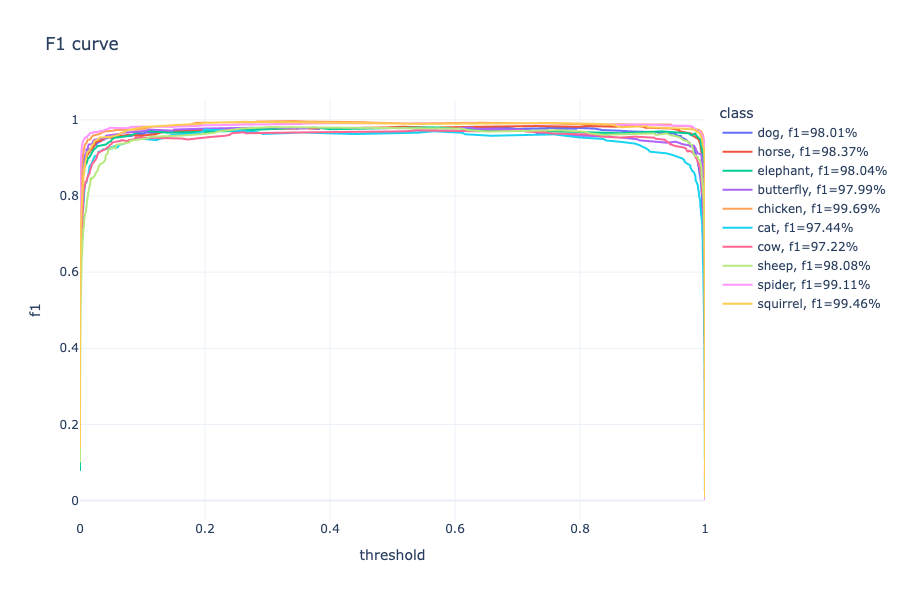

In [21]:
df = pd.DataFrame(df_dict)
px.line(df, x='threshold', y='f1', color='class', 
        width=800, height=600, title="F1 curve")

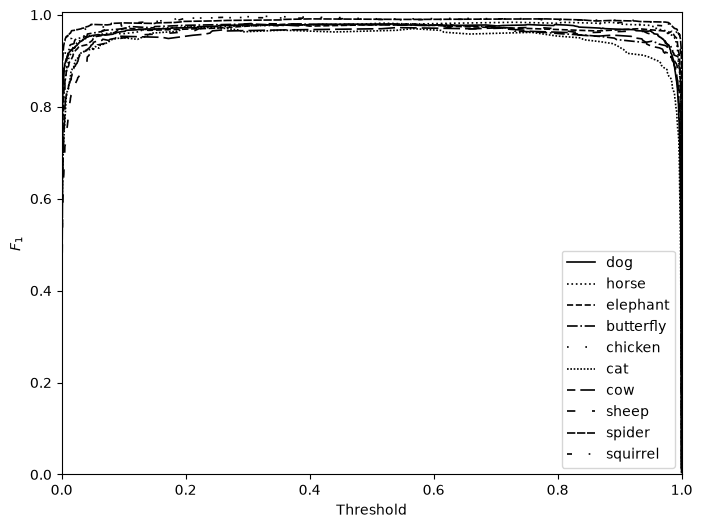

In [30]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
styles = ["solid", "dotted", "dashed", "dashdot", 
          (0, (1, 10)), (0, (1, 1)), (5, (10, 3)), (0, (5, 10)), (0, (5, 1)), (0, (3, 10, 1, 10))]
for style, class_name in zip(styles, images_classes_en):
    sub_df = df[df['class'].str.startswith(class_name)]
    threshold = sub_df.threshold
    f1 = sub_df.f1
    ax.plot(threshold, f1, linestyle=style, color='black', lw=1.2)
ax.legend(images_classes_en, loc='lower right')
ax.set_xlabel("Threshold")
ax.set_ylabel("$F_1$")
ax.set_xlim(0.0, 1)
ax.set_ylim(0.0, 1.005)
fig.savefig("vt-f1-threshold-all.svg")

# Perform classification using thresholds
With thresholds, our model can now produce "UNKNOWN" result (if all predictions are below threshold)

In [24]:
def denorm_image(img: np.ndarray) -> np.ndarray:
    res = np.array(img, copy=True)
    res = res.transpose((1, 2, 0))
    res *= np.array(data.NORM_STD) * 255
    res += np.array(data.NORM_MEAN) * 255
    res = res.astype(np.uint8)
    return res

In [25]:
with torch.no_grad():
    pred_probs = []
    pred_classes = []
    true_classes = []
    uncertains = []
    for batch_x, batch_y in test_loader:
        out_t = model(batch_x).logits
        probs_t = torch.softmax(out_t, -1)
        probs = probs_t.detach().numpy()
        batch_classes = batch_y.detach().numpy()
        for row_idx, true_class in enumerate(batch_classes):
            classes = []
            argmax_class = np.argmax(probs[row_idx])
            for class_idx in range(len(images_classes)):
                p = probs[row_idx, class_idx]
                if p > class_thresholds[class_idx]:
                    classes.append((p, class_idx))
            if len(classes) == 0:
                if len(uncertains) < 10:
                    print(f"Uncertain about {images_classes_en[true_class]}, "
                          f"argmax class {images_classes_en[argmax_class]}")
                uncertains.append(denorm_image(batch_x[row_idx].detach().numpy()))
            elif len(classes) == 1:
                c, p = classes[0]
                pred_classes.append(p)
                pred_probs.append(c)
                true_classes.append(true_class)
            elif len(classes) > 1:
                classes.sort(reverse=True)
                c, p = classes[0]
                pred_classes.append(p)
                pred_probs.append(c)
                true_classes.append(true_class)
len(uncertains), len(test_dataset)

Uncertain about squirrel, argmax class dog
Uncertain about squirrel, argmax class dog
Uncertain about horse, argmax class horse
Uncertain about dog, argmax class horse
Uncertain about dog, argmax class dog
Uncertain about dog, argmax class dog
Uncertain about dog, argmax class cow
Uncertain about cow, argmax class cow
Uncertain about horse, argmax class dog
Uncertain about sheep, argmax class horse


(11, 2421)

In [26]:
print(classification_report(true_classes, pred_classes, target_names=images_classes_en))

              precision    recall  f1-score   support

         dog       0.99      0.98      0.98       474
       horse       0.98      0.99      0.99       251
    elephant       0.98      1.00      0.99       112
   butterfly       0.98      0.97      0.97       163
     chicken       0.99      0.99      0.99       307
         cat       0.98      0.99      0.98       128
         cow       0.98      0.95      0.97       166
       sheep       0.97      0.98      0.98       143
      spider       0.99      0.99      0.99       500
    squirrel       0.98      0.99      0.99       166

    accuracy                           0.98      2410
   macro avg       0.98      0.98      0.98      2410
weighted avg       0.98      0.98      0.98      2410



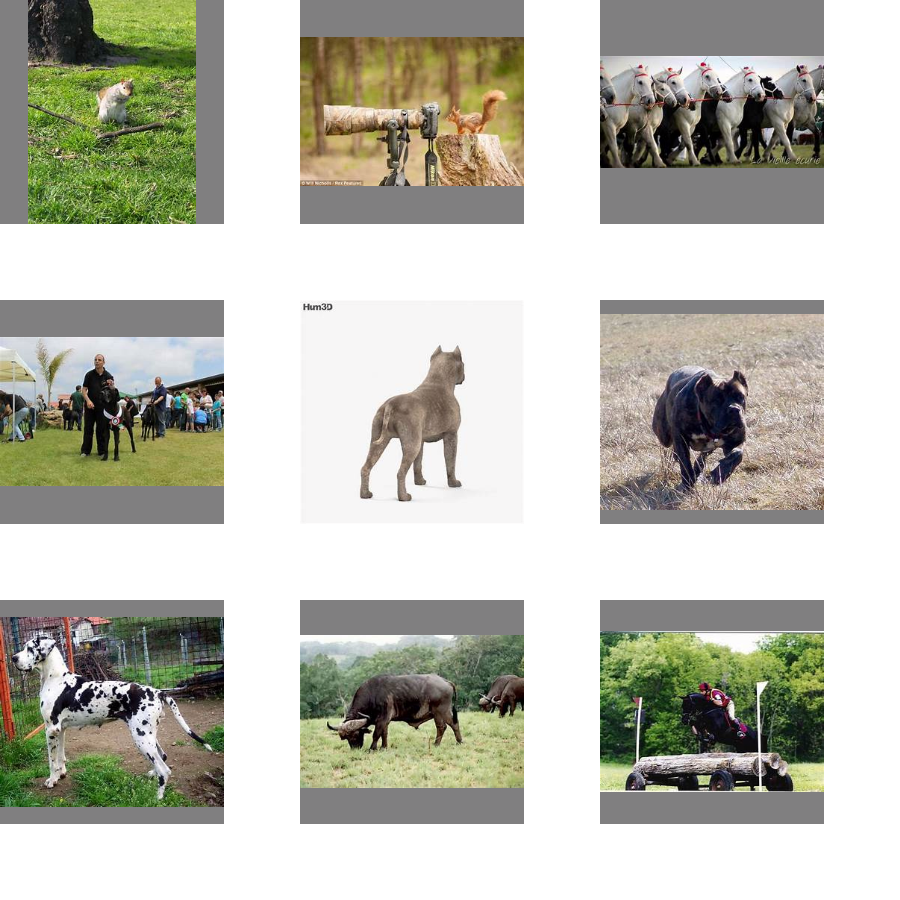

In [27]:
grid = Image.new("RGB", (3*300, 3*300), "white")
for row in range(3): 
    for col in range(3):
        grid.paste(Image.fromarray(uncertains[row*3+col]), (col*300, row*300))
grid

In [28]:
grid.save("uncertain-vt.png")